In [1]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes datasets gradio

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-mdblenih/unsloth_8711fd52089d4671999b226952866cf3
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-mdblenih/unsloth_8711fd52089d4671999b226952866cf3
  Resolved https://github.com/unslothai/unsloth.git to commit ffbc3a5f8da9df6265d48dfdf02757a92328156a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidanc

In [2]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-3B-Instruct",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Unsloth 2026.9.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [4]:
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template

# 1. Prepare the tokenizer for Llama-3.1/3.2 conversational guidelines natively
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1", # Industry standard for Llama 3 Instruct variants
)

# 2. Pull the raw legal dataset from Hugging Face
dataset = load_dataset("MeeraR/legal-qa-dataset", split="train")

# 3. Drop any corrupt or empty entries to protect learning curves
dataset = dataset.filter(lambda x: x["question"] is not None and x["answer"] is not None)

# 4. Shuffle and take a clean subset for fast processing
dataset = dataset.shuffle(seed=3407).select(range(min(800, len(dataset))))

(…)_legal_qa_dataset_unique_questions.jsonl:   0%|          | 0.00/792k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2375 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2375 [00:00<?, ? examples/s]

In [5]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only
import torch

# Define how each conversational block looks before it enters the trainer
def formatting_prompts_func(examples):
    instructions = examples["question"]
    outputs      = examples["answer"]
    texts = []

    for instruction, output in zip(instructions, outputs):
        messages = [
            {
                "role": "system",
                "content": "You are NyayaLlama, an expert Indian Legal AI Assistant. Provide thorough, multi-paragraph, and comprehensive explanations. Detail the context, specific articles, and sections of the Indian Penal Code (IPC) or the Constitution of India where relevant."
            },
            {"role": "user", "content": str(instruction)},
            {"role": "assistant", "content": str(output)}
        ]
        # Format the text natively using Unsloth's structure
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)

    return texts # FIX: Returning a raw list of strings instead of a dictionary!

# Configure optimal hyperparameter metrics for Capstone evaluation
training_args = SFTConfig(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    num_train_epochs=3,          # Trains across full data 3 times for strong accuracy
    learning_rate=2.0e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=1,
    optim="paged_adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    output_dir="outputs",
)

# Initialize Trainer with native formatting functions
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    formatting_func=formatting_prompts_func, # Natively wraps data safely
    args=training_args,
)

# Apply response masking using standard strings to protect target learning patterns
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
    response_part="<|start_header_id|>assistant<|end_header_id|>\n\n"
)

# Run the training loop
trainer_stats = trainer.train()

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/800 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 3 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:3239: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-package

Step,Training Loss
1,3.208855
2,3.785897
3,3.365731
4,3.021099
5,2.228887
6,2.835182
7,2.871692
8,2.334812
9,2.321651
10,2.102382


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-300/tokenizer_config.json.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get training history
df_metrics = pd.DataFrame(trainer.state.log_history)

print("=" * 60)
print("FINAL TRAINING STATISTICS")
print("=" * 60)

# Safely read metrics
runtime = trainer_stats.metrics.get("train_runtime", None)
train_loss = trainer_stats.metrics.get("train_loss", None)

# Epoch can be stored in trainer.state instead of trainer_stats
epoch = trainer.state.epoch

if runtime is not None:
    print(f"Total Training Time : {runtime:.2f} seconds")
    print(f"Total Training Time : {runtime/60:.2f} minutes")

if epoch is not None:
    print(f"Epochs Completed    : {epoch:.2f}")

if train_loss is not None:
    print(f"Final Training Loss : {train_loss:.4f}")

print("\nAvailable metric keys:")
print(list(trainer_stats.metrics.keys()))

print("\nTraining log columns:")
print(list(df_metrics.columns))

FINAL TRAINING STATISTICS
Total Training Time : 743.65 seconds
Total Training Time : 12.39 minutes
Epochs Completed    : 3.00
Final Training Loss : 0.8000

Available metric keys:
['train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']

Training log columns:
['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


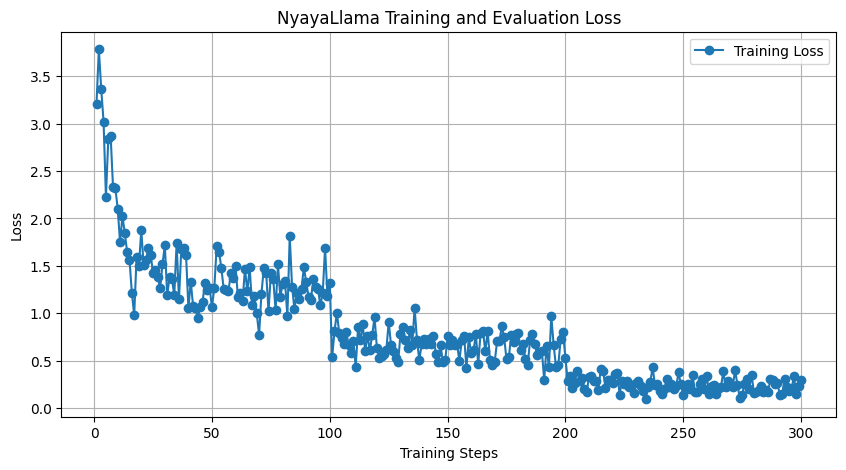

Training-loss points: 300
Evaluation-loss points: 0


In [8]:
import matplotlib.pyplot as plt

df_metrics = pd.DataFrame(trainer.state.log_history)

# Training loss
train_loss_df = df_metrics[
    df_metrics["loss"].notna()
] if "loss" in df_metrics.columns else pd.DataFrame()

# Evaluation loss
eval_loss_df = df_metrics[
    df_metrics["eval_loss"].notna()
] if "eval_loss" in df_metrics.columns else pd.DataFrame()

plt.figure(figsize=(10, 5))

if not train_loss_df.empty:
    plt.plot(
        train_loss_df["step"],
        train_loss_df["loss"],
        marker="o",
        label="Training Loss"
    )

if not eval_loss_df.empty:
    plt.plot(
        eval_loss_df["step"],
        eval_loss_df["eval_loss"],
        marker="o",
        label="Evaluation Loss"
    )

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("NyayaLlama Training and Evaluation Loss")
plt.grid(True)
plt.legend()
plt.show()

print("Training-loss points:", len(train_loss_df))
print("Evaluation-loss points:", len(eval_loss_df))

In [9]:
import os

FINAL_ADAPTER_PATH = "/content/drive/MyDrive/NyayaLlama_Deployment/nyayallama_final_adapter"

os.makedirs(FINAL_ADAPTER_PATH, exist_ok=True)

model.save_pretrained(FINAL_ADAPTER_PATH)
tokenizer.save_pretrained(FINAL_ADAPTER_PATH)

print("✅ Adapter permanently saved to Google Drive:")
print(FINAL_ADAPTER_PATH)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/NyayaLlama_Deployment/nyayallama_final_adapter/tokenizer_config.json.


✅ Adapter permanently saved to Google Drive:
/content/drive/MyDrive/NyayaLlama_Deployment/nyayallama_final_adapter


In [10]:
import os

print("Files saved in final adapter:")
for file in os.listdir(FINAL_ADAPTER_PATH):
    print(file)

Files saved in final adapter:
adapter_config.json
README.md
adapter_model.safetensors
tokenizer_config.json
tokenizer.json
chat_template.jinja


In [11]:
evaluation_questions = [
    {
        "question": "What is the purpose of Article 14 of the Constitution of India?",
        "topic": "Constitution - Article 14"
    },
    {
        "question": "What protection is provided by Article 21 of the Constitution of India?",
        "topic": "Constitution - Article 21"
    },
    {
        "question": "What is Article 32 of the Constitution of India concerned with?",
        "topic": "Constitution - Article 32"
    },
    {
        "question": "What is the Bharatiya Nyaya Sanhita, 2023?",
        "topic": "BNS"
    },
    {
        "question": "What law did the Bharatiya Nyaya Sanhita replace?",
        "topic": "BNS and IPC"
    },
    {
        "question": "When did the Bharatiya Nyaya Sanhita generally come into force?",
        "topic": "BNS commencement"
    },
    {
        "question": "What is the Bharatiya Nagarik Suraksha Sanhita, 2023?",
        "topic": "BNSS"
    },
    {
        "question": "What is the Bharatiya Sakshya Adhiniyam, 2023?",
        "topic": "BSA"
    },
    {
        "question": "What is the difference between substantive criminal law and criminal procedure?",
        "topic": "Criminal law concepts"
    },
    {
        "question": "Why is it important to distinguish the BNS from the former IPC?",
        "topic": "BNS and IPC"
    }
]

print("Number of evaluation questions:", len(evaluation_questions))

Number of evaluation questions: 10


In [15]:
import torch

# Make sure the model is in inference mode
FastLanguageModel.for_inference(model)

def generate_response(user_query, history=None):

    if history is None:
        history = []

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        }
    ]

    # Add conversation history
    for item in history:

        if isinstance(item, dict):

            role = item.get("role")
            content = item.get("content")

            if role in ["user", "assistant"] and content:
                messages.append({
                    "role": role,
                    "content": content
                })

    # Current question
    messages.append({
        "role": "user",
        "content": str(user_query)
    })

    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    eos_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")

    termination_ids = [
        tokenizer.eos_token_id,
        eos_id
    ]

    with torch.no_grad():

        outputs = model.generate(
            input_ids,
            max_new_tokens=512,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.1,
            eos_token_id=termination_ids,
            pad_token_id=tokenizer.eos_token_id
        )

    prompt_length = input_ids.shape[-1]

    answer_tokens = outputs[0][prompt_length:]

    answer = tokenizer.decode(
        answer_tokens,
        skip_special_tokens=True
    )

    return answer.strip()

In [14]:
SYSTEM_PROMPT = """
You are NyayaLlama, an Indian Legal Information Assistant.

Provide clear, structured and educational explanations of Indian law.

When relevant, identify the applicable constitutional provision,
statute, or legal section.

For current criminal-law questions, distinguish among the
Bharatiya Nyaya Sanhita (BNS), Bharatiya Nagarik Suraksha Sanhita
(BNSS), and Bharatiya Sakshya Adhiniyam (BSA), as applicable.

Do not invent legal provisions, section numbers, cases, or citations.

If the available information is insufficient or the question depends
on specific facts, clearly state that limitation.

Your responses are for educational and informational purposes and
are not a substitute for advice from a qualified legal professional.
"""

print("✅ SYSTEM_PROMPT loaded successfully.")

✅ SYSTEM_PROMPT loaded successfully.


In [16]:
test_question = "What is Article 21 of the Constitution of India?"

answer = generate_response(test_question)

print("QUESTION:")
print(test_question)

print("\nNYAYALLAMA RESPONSE:")
print(answer)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:
What is Article 21 of the Constitution of India?

NYAYALLAMA RESPONSE:
The right to life and liberty.


In [17]:
import os

print("Adapter location:")
print(FINAL_ADAPTER_PATH)

print("\nAdapter files:")
for f in os.listdir(FINAL_ADAPTER_PATH):
    print("✓", f)

Adapter location:
/content/drive/MyDrive/NyayaLlama_Deployment/nyayallama_final_adapter

Adapter files:
✓ adapter_config.json
✓ README.md
✓ adapter_model.safetensors
✓ tokenizer_config.json
✓ tokenizer.json
✓ chat_template.jinja


In [18]:
!pip install -q huggingface_hub

In [19]:
from huggingface_hub import login

login()

In [20]:
from huggingface_hub import whoami

info = whoami()
print("✅ Logged in successfully!")
print("Hugging Face username:", info["name"])

✅ Logged in successfully!
Hugging Face username: bhuvanteja03


In [22]:
from huggingface_hub import HfApi

api = HfApi()

HF_USERNAME = "YOUR_HUGGINGFACE_USERNAME"
MODEL_REPO = f"bhuvanteja03/nyayallama-final-adapter"

api.create_repo(
    repo_id=MODEL_REPO,
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    folder_path="/content/drive/MyDrive/NyayaLlama_Deployment/nyayallama_final_adapter",
    repo_id=MODEL_REPO,
    repo_type="model"
)

print("✅ Adapter uploaded successfully!")
print("Model repository:")
print(f"https://huggingface.co/{MODEL_REPO}")

✅ Adapter uploaded successfully!
Model repository:
https://huggingface.co/bhuvanteja03/nyayallama-final-adapter


In [23]:
import gradio as gr
import torch
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

# ============================================================
# MODEL CONFIGURATION
# ============================================================

BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct"
ADAPTER_PATH = "bhuvanteja03/nyayallama-final-adapter"
MAX_SEQ_LENGTH = 2048

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

print("Loading NyayaLlama...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.1"
)

FastLanguageModel.for_inference(model)

print("✅ NyayaLlama loaded successfully!")

# ============================================================
# SYSTEM PROMPT
# ============================================================

SYSTEM_PROMPT = """
You are NyayaLlama, an Indian Legal Information Assistant.

Provide clear, structured and educational explanations of Indian law.

When relevant, identify the applicable constitutional provision,
statute, or legal section.

For current criminal-law questions, distinguish among the
Bharatiya Nyaya Sanhita (BNS), Bharatiya Nagarik Suraksha Sanhita
(BNSS), and Bharatiya Sakshya Adhiniyam (BSA), as applicable.

Do not invent legal provisions, section numbers, cases, or citations.

If the available information is insufficient or the question depends
on specific facts, clearly state that limitation.

Your responses are for educational and informational purposes and
are not a substitute for advice from a qualified legal professional.
"""

# ============================================================
# RESPONSE GENERATION
# ============================================================

def generate_legal_response(user_query, history):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        }
    ]

    # Add previous conversation
    if history:
        for item in history:

            # New Gradio history format
            if isinstance(item, dict):
                role = item.get("role")
                content = item.get("content")

                if role in ["user", "assistant"] and content:
                    messages.append({
                        "role": role,
                        "content": content
                    })

            # Older Gradio format
            elif isinstance(item, (list, tuple)) and len(item) == 2:
                user_message, assistant_message = item

                if user_message:
                    messages.append({
                        "role": "user",
                        "content": user_message
                    })

                if assistant_message:
                    messages.append({
                        "role": "assistant",
                        "content": assistant_message
                    })

    # Current question
    messages.append({
        "role": "user",
        "content": user_query
    })

    # Determine device
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Convert conversation into model input
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(device)

    # End-of-turn token
    eos_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")

    termination_ids = [
        tokenizer.eos_token_id,
        eos_id
    ]

    # Generate response
    with torch.no_grad():

        outputs = model.generate(
            input_ids,
            max_new_tokens=512,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.1,
            eos_token_id=termination_ids,
            pad_token_id=tokenizer.eos_token_id
        )

    # Remove prompt from generated output
    prompt_length = input_ids.shape[-1]

    response_tokens = outputs[0][prompt_length:]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    ).strip()

    return response


# ============================================================
# GRADIO INTERFACE
# ============================================================

demo = gr.ChatInterface(
    fn=generate_legal_response,
    title="⚖️ NyayaLlama: Indian Legal AI Assistant",
    description=(
        "An Indian Legal Information Assistant powered by "
        "Llama 3.2 3B and LoRA fine-tuning."
    )
)

# ============================================================
# LAUNCH
# ============================================================

if __name__ == "__main__":
    demo.launch()

Loading NyayaLlama...
==((====))==  Unsloth 2026.9.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✅ NyayaLlama loaded successfully!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://420b3777bc40a53336.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
# ============================================================
# NYAYALLAMA DIRECT MODEL TEST
# ============================================================

test_question = "What is Article 21 of the Constitution of India?"

messages = [
    {
        "role": "system",
        "content": SYSTEM_PROMPT
    },
    {
        "role": "user",
        "content": test_question
    }
]

device = "cuda" if torch.cuda.is_available() else "cpu"

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
).to(device)

eos_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")

with torch.no_grad():
    outputs = model.generate(
        input_ids,
        max_new_tokens=300,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.1,
        eos_token_id=[tokenizer.eos_token_id, eos_id],
        pad_token_id=tokenizer.eos_token_id
    )

prompt_length = input_ids.shape[-1]

response_tokens = outputs[0][prompt_length:]

response = tokenizer.decode(
    response_tokens,
    skip_special_tokens=True
).strip()

print("QUESTION:")
print(test_question)

print("\nNYAYALLAMA RESPONSE:")
print(response)

Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:
What is Article 21 of the Constitution of India?

NYAYALLAMA RESPONSE:
The right to life and liberty.


In [25]:
# ============================================================
# NYAYALLAMA - DETAILED RESPONSE TEST
# ============================================================

test_question = """
Explain Article 21 of the Constitution of India in 3 to 5 sentences.
Mention what it protects and briefly explain its importance.
Do not invent any section numbers or cases.
"""

messages = [
    {
        "role": "system",
        "content": SYSTEM_PROMPT
    },
    {
        "role": "user",
        "content": test_question
    }
]

device = "cuda" if torch.cuda.is_available() else "cpu"

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
).to(device)

eos_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")

with torch.no_grad():
    outputs = model.generate(
        input_ids,
        max_new_tokens=400,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.1,
        eos_token_id=[tokenizer.eos_token_id, eos_id],
        pad_token_id=tokenizer.eos_token_id
    )

prompt_length = input_ids.shape[-1]

response_tokens = outputs[0][prompt_length:]

response = tokenizer.decode(
    response_tokens,
    skip_special_tokens=True
).strip()

print("QUESTION:")
print(test_question)

print("\nNYAYALLAMA RESPONSE:")
print(response)

Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:

Explain Article 21 of the Constitution of India in 3 to 5 sentences.
Mention what it protects and briefly explain its importance.
Do not invent any section numbers or cases.


NYAYALLAMA RESPONSE:
Kesavananda Bharati vs State of Kerala is a landmark decision that discusses procedural fairness and the right to be heard.


In [26]:
test_question = """
What is the Bharatiya Nyaya Sanhita (BNS)?
Explain its purpose and identify what major criminal law it replaced.
"""

messages = [
    {
        "role": "system",
        "content": SYSTEM_PROMPT
    },
    {
        "role": "user",
        "content": test_question
    }
]

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        input_ids,
        max_new_tokens=400,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.1,
        eos_token_id=[tokenizer.eos_token_id, eos_id],
        pad_token_id=tokenizer.eos_token_id
    )

prompt_length = input_ids.shape[-1]

response_tokens = outputs[0][prompt_length:]

response = tokenizer.decode(
    response_tokens,
    skip_special_tokens=True
).strip()

print("QUESTION:")
print(test_question)

print("\nNYAYALLAMA RESPONSE:")
print(response)

Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION:

What is the Bharatiya Nyaya Sanhita (BNS)?
Explain its purpose and identify what major criminal law it replaced.


NYAYALLAMA RESPONSE:
It's the Criminal Procedure Code of India.


In [27]:
# ============================================================
# TEST BASE MODEL WITHOUT LoRA ADAPTER
# ============================================================

test_question = """
What is the Bharatiya Nyaya Sanhita (BNS)?
Explain its purpose and identify what major criminal law it replaced.
"""

messages = [
    {
        "role": "system",
        "content": """
You are an Indian legal information assistant.
Give accurate, concise educational explanations.
Do not invent legal provisions or citations.
"""
    },
    {
        "role": "user",
        "content": test_question
    }
]

device = "cuda" if torch.cuda.is_available() else "cpu"

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
).to(device)

eos_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")

# Temporarily disable LoRA
with model.disable_adapter():
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=250,
            temperature=0.1,
            top_p=0.9,
            repetition_penalty=1.05,
            eos_token_id=[tokenizer.eos_token_id, eos_id],
            pad_token_id=tokenizer.eos_token_id
        )

prompt_length = input_ids.shape[-1]

response_tokens = outputs[0][prompt_length:]

response = tokenizer.decode(
    response_tokens,
    skip_special_tokens=True
).strip()

print("BASE MODEL WITHOUT LoRA:")
print(response)

Both `max_new_tokens` (=250) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL WITHOUT LoRA:
The Bharatiya Nyaya Sanhita (BNS) is a comprehensive codification of Indian criminal law. It was enacted in 1955 by the Government of India.

The BNS replaced the Indian Penal Code (IPC), 1860, which was the existing criminal law code at that time. The IPC was a British colonial-era legislation that had been in force since 1860.

The main purpose of the BNS was to consolidate and modernize the Indian criminal law, making it more comprehensive and aligned with the country's social and cultural values. However, the BNS was never implemented due to various reasons, including opposition from the Indian National Congress and other political parties.

As a result, the IPC remained in force until the Indian government decided to replace it with the Indian Penal Code (Amendment) Act, 1973, which made some amendments to the IPC. Later, the Indian government decided to replace the IPC with the Indian Penal Code (Amendment) Act, 2005, but this was also not implemented.

I

In [53]:
%%writefile app.py

import gradio as gr
import torch
import traceback

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

MODEL_ID = "bhuvanteja03/nyayallama-final-adapter"

SYSTEM_PROMPT = """You are NyayaLlama, an Indian Legal Information Assistant.

Provide clear, structured, educational and reasonably detailed explanations
of Indian law.

Do not give one-sentence answers unless the question genuinely requires
only a very short answer.

For most legal questions, provide 3 to 6 sentences or short paragraphs.

When relevant:
- identify the applicable Article, Act, or legal section
- explain what the provision means in simple language
- explain its practical significance
- give a simple example when useful

For constitutional questions, mention the relevant Article and explain
its meaning clearly.

For current criminal-law questions, distinguish among the Bharatiya
Nyaya Sanhita (BNS), Bharatiya Nagarik Suraksha Sanhita (BNSS), and
Bharatiya Sakshya Adhiniyam (BSA), as applicable.

Do not invent legal provisions, section numbers, cases, or citations.

If the available information is insufficient or the question depends on
specific facts, clearly state that limitation.

Use simple language suitable for a student learning Indian law.

Responses are for educational and informational purposes only and are
not a substitute for advice from a qualified legal professional.
"""

print("======================================")
print("Starting NyayaLlama")
print("======================================")

# -------------------------------
# TOKENIZER
# -------------------------------

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded.")


# -------------------------------
# MODEL
# -------------------------------

print("Loading model...")

if torch.cuda.is_available():

    print("CUDA detected.")

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    )

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto"
    )

else:

    print("CPU detected.")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID
    )

model.eval()

MODEL_DEVICE = next(model.parameters()).device

print("Model loaded successfully.")
print("Device:", MODEL_DEVICE)
print("======================================")


# -------------------------------
# GENERATION
# -------------------------------

def generate_answer(question):

    try:

        print("\n======================================")
        print("QUESTION:")
        print(question)

        # Force normal string
        question = str(question).strip()

        question = question + """

        Please answer this question in a reasonably detailed way.
        Give 4 to 6 clear sentences.
        Explain the legal concept in simple language.
        Mention the relevant Article, Act, or section when applicable.
        Give a simple example if useful.
        Do not stop after only one sentence.
        """

        # ---------------------------------
        # MANUAL LLAMA 3 CHAT PROMPT
        # ---------------------------------

        prompt = (
            "<|begin_of_text|>"
            "<|start_header_id|>system<|end_header_id|>\n\n"
            + SYSTEM_PROMPT +
            "\n<|eot_id|>"
            "<|start_header_id|>user<|end_header_id|>\n\n"
            + question +
            "\n<|eot_id|>"
            "<|start_header_id|>assistant<|end_header_id|>\n\n"
        )

        print("Prompt created.")

        # Tokenize
        encoded = tokenizer(
            prompt,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].to(MODEL_DEVICE)
        attention_mask = encoded["attention_mask"].to(MODEL_DEVICE)

        print("Input tokens:", input_ids.shape[-1])
        print("Starting generation...")

        with torch.no_grad():

            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,

                # Force the model to produce a reasonably detailed answer
                min_new_tokens=80,
                max_new_tokens=400,

                # Controlled sampling gives more natural explanations
                do_sample=True,
                temperature=0.45,
                top_p=0.90,

                repetition_penalty=1.15,

                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        # Only take newly generated tokens
        new_tokens = outputs[0][input_ids.shape[-1]:]

        answer = tokenizer.decode(
            new_tokens,
            skip_special_tokens=True
        ).strip()


        print("Generated answer:")
        print(answer)
        print("======================================")

        if not answer:
            return "No answer was generated. Please try again."

        return answer

    except Exception as e:

        print("\n\n========== REAL ERROR ==========")
        print("ERROR TYPE:", type(e))
        print("ERROR:", repr(e))
        print("\nFULL TRACEBACK:")
        traceback.print_exc()
        print("================================\n")

        return (
            "Generation failed.\n\n"
            "Error type: "
            + str(type(e).__name__)
            + "\n"
            + "Error details: "
            + repr(e)
        )


# -------------------------------
# CHAT-STYLE GRADIO UI
# -------------------------------

def chat_response(message, history):

    # Build the question using previous conversation
    if history:

        conversation = ""

        for item in history:

            if isinstance(item, dict):

                role = item.get("role")
                content = item.get("content")

                if isinstance(content, str):

                    if role == "user":
                        conversation += "\nUser: " + content

                    elif role == "assistant":
                        conversation += "\nAssistant: " + content

        full_question = conversation + "\nUser: " + str(message)

    else:

        full_question = str(message)

    # Use the EXACT working generation function
    return generate_answer(full_question)


demo = gr.ChatInterface(
    fn=chat_response,
    title="⚖️ NyayaLlama: Indian Legal AI Assistant",
    description=(
        "Educational Indian legal information assistant "
        "powered by Llama 3.2 3B and LoRA fine-tuning."
    ),
    textbox=gr.Textbox(
        placeholder="Ask an Indian legal question...",
        container=True
    )
)

if __name__ == "__main__":

    demo.launch(
        share=True,
        debug=True
    )

Overwriting app.py


In [29]:
import os

print("app.py exists:", os.path.exists("/content/app.py"))

if os.path.exists("/content/app.py"):
    print("✅ app.py created successfully!")

app.py exists: True
✅ app.py created successfully!


In [30]:
%%writefile requirements.txt

torch
transformers
peft
accelerate
bitsandbytes
gradio
huggingface_hub

Writing requirements.txt


In [31]:
%%writefile README.md

---
title: NyayaLlama Indian Legal AI Assistant
emoji: ⚖️
colorFrom: blue
colorTo: indigo
sdk: gradio
app_file: app.py
---

# NyayaLlama: Indian Legal AI Assistant

## Project Overview

NyayaLlama is an educational Indian Legal Information Assistant
developed using Llama 3.2 3B Instruct and LoRA fine-tuning.

The project explores the use of parameter-efficient fine-tuning
for an Indian legal question-answering assistant.

## Technology Stack

- Llama 3.2 3B Instruct
- LoRA / PEFT
- Transformers
- BitsAndBytes 4-bit quantization
- PyTorch
- Gradio
- Hugging Face

## Model

The application uses a Llama 3.2 3B base model together with a
LoRA adapter trained on an Indian legal question-answering dataset.

## Features

- Conversational legal question answering
- Constitutional law questions
- Indian criminal-law terminology
- BNS / BNSS / BSA awareness
- Educational legal explanations

## Important Limitation

This is a student research prototype.

The model can generate incorrect or incomplete legal information
and must not be treated as an authoritative legal source.

Users should verify legal information against current legislation,
official government sources and qualified legal professionals.

## Disclaimer

This application provides educational and informational content only.
It does not provide legal advice and does not establish an
attorney-client relationship.

Writing README.md


In [32]:
import os

files = [
    "app.py",
    "requirements.txt",
    "README.md"
]

for file in files:
    if os.path.exists("/content/" + file):
        print("✅", file)
    else:
        print("❌", file)

✅ app.py
✅ requirements.txt
✅ README.md


In [33]:
!pip install -q transformers peft accelerate bitsandbytes gradio

In [35]:
# Change the existing app.py launch line for Colab testing

with open("/content/app.py", "r") as f:
    app_code = f.read()

app_code = app_code.replace(
    "demo.launch()",
    "demo.launch(share=True)"
)

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("✅ app.py updated for Colab public testing")

✅ app.py updated for Colab public testing


In [36]:
with open("/content/app.py", "r") as f:
    code = f.read()

print(code[-300:])

ional Indian legal information assistant "
        "powered by Llama 3.2 3B and LoRA fine-tuning."
    )
)


# ============================================================
# LAUNCH
# ============================================================

if __name__ == "__main__":
    demo.launch(share=True)



In [54]:
!python app.py

/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:301: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
Starting NyayaLlama
Loading tokenizer...
Tokenizer loaded.
Loading model...
CUDA detected.
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
/usr/local/lib/python3.13/dist-packages/transformers/quantizers/auto

In [55]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>